In [3]:
import pandas as pd
import numpy as np
import matplotlib as plt
import warnings

In [4]:
df = pd.read_csv(r"C:\Users\USER\OneDrive\Desktop\Restaurant_Reviews.tsv", sep="\t")


In [5]:
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [6]:
df.shape

(1000, 2)

In [7]:
df.isnull().sum()

Review    0
Liked     0
dtype: int64

In [8]:
df['Liked'].value_counts()

Liked
1    500
0    500
Name: count, dtype: int64

In [9]:
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [10]:
df['char_count']=df['Review'].apply(len)

In [11]:
df.head()

,Review,Liked,char_count
0,Wow... Loved this place.,1,24
1,Crust is not good.,0,18
2,Not tasty and the texture was just nasty.,0,41
3,Stopped by during the late May bank holiday of...,1,87
4,The selection on the menu was great and so wer...,1,59


In [12]:
df['word_count']=df['Review'].apply(lambda x :len(str(x).split()))

In [13]:
df.head()

,Review,Liked,char_count,word_count
0,Wow... Loved this place.,1,24,4
1,Crust is not good.,0,18,4
2,Not tasty and the texture was just nasty.,0,41,8
3,Stopped by during the late May bank holiday of...,1,87,15
4,The selection on the menu was great and so wer...,1,59,12


In [14]:
import nltk

In [15]:
nltk.download('punkt')

[nltk_data] Error loading punkt: <urlopen error [WinError 10060] A
[nltk_data]     connection attempt failed because the connected party
[nltk_data]     did not properly respond after a period of time, or
[nltk_data]     established connection failed because connected host
[nltk_data]     has failed to respond>


False

In [16]:
df['sent_count']=df['Review'].apply(lambda x :len(nltk.sent_tokenize(str(x))))

In [17]:
df.head()

,Review,Liked,char_count,word_count,sent_count
0,Wow... Loved this place.,1,24,4,2
1,Crust is not good.,0,18,4,1
2,Not tasty and the texture was just nasty.,0,41,8,1
3,Stopped by during the late May bank holiday of...,1,87,15,1
4,The selection on the menu was great and so wer...,1,59,12,1


In [18]:
df[df['Liked']==1]['char_count'].mean()

55.88

In [19]:
df[df['Liked']==0]['char_count'].mean()

60.75

In [20]:
import re
from nltk.corpus import stopwords

In [21]:
all_stopwords = stopwords.words('english')

In [22]:
all_stopwords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [23]:
from nltk.stem import PorterStemmer

In [24]:
ps = PorterStemmer()

In [25]:
import re

# Define custom stopwords
custom_stopwords = {
    'don', "don't", 'ain', 'aren', "aren't", 'couldn', "couldn't",
    'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't",
    'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't",
    'needn', "needn't", 'shan', "shan't", 'no', 'not', 'shouldn', "shouldn't",
    'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"
}

# Initialize
corpus = []
ps = PorterStemmer()
stop_words = set(stopwords.words("english")) - custom_stopwords

# Text preprocessing loop
for i in range(len(df)):
    review = re.sub('[^a-zA-Z]', ' ', df['Review'][i])   # Remove non-letters
    review = review.lower()                                # Lowercase
    review = review.split()                                # Tokenize
    review = [ps.stem(word) for word in review if word not in stop_words]  # Remove stopwords + stem
    review = " ".join(review)                              # Rejoin to sentence
    corpus.append(review)

In [26]:
df['processed_text']=corpus

In [27]:
df.head()

,Review,Liked,char_count,word_count,sent_count,processed_text
0,Wow... Loved this place.,1,24,4,2,wow love place
1,Crust is not good.,0,18,4,1,crust not good
2,Not tasty and the texture was just nasty.,0,41,8,1,not tasti textur nasti
3,Stopped by during the late May bank holiday of...,1,87,15,1,stop late may bank holiday rick steve recommen...
4,The selection on the menu was great and so wer...,1,59,12,1,select menu great price


In [28]:
from wordcloud import WordCloud


In [29]:
wc = WordCloud(width=500, height=500, min_font_size=8, background_color="white")

In [30]:
# Generate the word cloud using processed text from reviews that were liked (Liked == 1)
pos = wc.generate(df[df['Liked'] == 1]['processed_text'].str.cat(sep=" "))

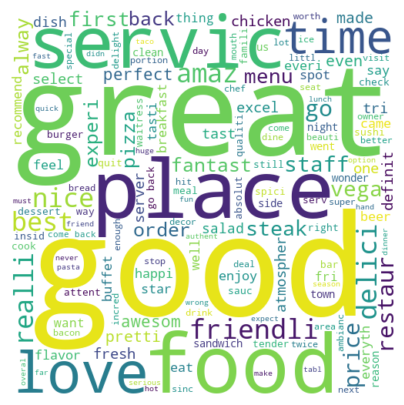

In [31]:
import matplotlib.pyplot as plt

# Display the word cloud
plt.figure(figsize=(5, 5))
plt.imshow(pos, interpolation="bilinear")
plt.axis("off")  # Hide the axes
plt.show()


In [32]:
pos = wc.generate(df[df['Liked'] == 0]['processed_text'].str.cat(sep=" "))

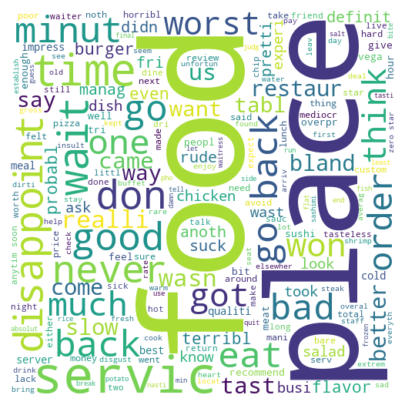

In [33]:
# Display the word cloud
plt.figure(figsize=(5, 5))
plt.imshow(pos, interpolation="bilinear")
plt.axis("off")  # Hide the axes
plt.show()


In [34]:
df.head()

,Review,Liked,char_count,word_count,sent_count,processed_text
0,Wow... Loved this place.,1,24,4,2,wow love place
1,Crust is not good.,0,18,4,1,crust not good
2,Not tasty and the texture was just nasty.,0,41,8,1,not tasti textur nasti
3,Stopped by during the late May bank holiday of...,1,87,15,1,stop late may bank holiday rick steve recommen...
4,The selection on the menu was great and so wer...,1,59,12,1,select menu great price


In [35]:
from sklearn.feature_extraction.text import CountVectorizer

In [36]:
cv = CountVectorizer(max_features=1500)

In [37]:
X = cv.fit_transform(corpus).toarray()


In [38]:
X


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [39]:
X.shape

(1000, 1500)

In [40]:
y = df['Liked']

In [41]:
y

0      1
1      0
2      0
3      1
4      1
      ..
995    0
996    0
997    0
998    0
999    0
Name: Liked, Length: 1000, dtype: int64

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [44]:
from sklearn.naive_bayes import GaussianNB

In [45]:
nb= GaussianNB()
nb.fit(X_train,y_train)
y_pred = nb.predict(X_test)


In [46]:
from sklearn.metrics import accuracy_score

In [47]:
accuracy_score(y_test,y_pred)

0.68

In [48]:
from sklearn.linear_model import LogisticRegression
lr= LogisticRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
accuracy_score(y_test,y_pred)


0.79

In [49]:
from sklearn.ensemble import RandomForestClassifier
rf= RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)


0.795

In [50]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))


Decision Tree Accuracy: 0.72


In [51]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred))


SVM Accuracy: 0.8


In [52]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))


XGBoost Accuracy: 0.74


In [53]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier()
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)

print("Neural Network Accuracy:", accuracy_score(y_test, y_pred))


Neural Network Accuracy: 0.75


In [54]:
import joblib

# Save the trained model
joblib.dump(svm, 'svm_model.pkl')

print("Model saved successfully!")


Model saved successfully!
